## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

## Data Overview

In [2]:
df = pd.read_csv("../data/raw/netflix_titles.csv")

In [3]:
df.rename(columns={"release_year":"year", "listed_in":"genre"}, inplace=True)

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   show_id      8807 non-null   str  
 1   type         8807 non-null   str  
 2   title        8807 non-null   str  
 3   director     6173 non-null   str  
 4   cast         7982 non-null   str  
 5   country      7976 non-null   str  
 6   date_added   8797 non-null   str  
 7   year         8807 non-null   int64
 8   rating       8803 non-null   str  
 9   duration     8804 non-null   str  
 10  genre        8807 non-null   str  
 11  description  8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
df.nunique()

show_id        8807
type              2
title          8807
director       4528
cast           7692
country         748
date_added     1767
year             74
rating           17
duration        220
genre           514
description    8775
dtype: int64

The dataset includes 8,807 Netflix titles across 12 columns, with both Movies and TV Shows represented. It provides the main information needed for this analysis, including content type, release year, rating, duration, genre, country, and date added.

The first inspection suggests that the core analysis columns are in good condition overall. The main missing-value issues appear in `director`, `cast`, and `country`, which means these fields should be handled carefully before using them for deeper analysis.

## Data Cleaning

The first step was to check missing values across the dataset. `director`, `cast`, and `country` had noticeable gaps, but dropping all rows with missing values in these columns would remove too much useful data. For that reason, I filled them with `"Unknown"` instead. For columns with only a few missing entries, such as `date_added`, `rating`, and `duration`, I dropped the affected rows since the data loss was very small.

After handling missing values, I cleaned several columns to prepare them for feature engineering. The `duration` column was converted into a numeric format by removing labels such as `"min"` and `"Seasons"`. I also simplified the `genre` column by removing redundant labels such as `"Movies"` and `"TV Shows"`, then split the remaining genres into lists. Finally, `date_added` was parsed as a datetime column, and a `month` column was extracted for later analysis.

After these cleaning steps, the dataset was reduced from 8,807 to 8,790 rows and was ready for the next stage of analysis.

In [7]:
df.shape

(8807, 12)

In [8]:
df.isna().sum()

show_id           0
type              0
title             0
director       2634
cast            825
country         831
date_added       10
year              0
rating            4
duration          3
genre             0
description       0
dtype: int64

In [9]:
threshold = len(df) * 0.05
print(threshold)

440.35


In [10]:
columns_to_drop = df.columns[(df.isna().sum() <= threshold) & (df.isna().sum() > 0)]
print(columns_to_drop)

Index(['date_added', 'rating', 'duration'], dtype='str')


In [11]:
df.dropna(subset=columns_to_drop, inplace=True)
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

In [12]:
df.isna().sum()

show_id        0
type           0
title          0
director       0
cast           0
country        0
date_added     0
year           0
rating         0
duration       0
genre          0
description    0
dtype: int64

In [13]:
df.shape

(8790, 12)

In [14]:
df["duration"] = df["duration"].str.replace(" min", "", regex=False)
df["duration"] = df["duration"].str.replace(r" Seasons?", "", regex=True).astype("int")

df["genre"] = df["genre"].str.replace(" Movies", "", regex=False)
df["genre"] = df["genre"].str.replace(" TV Shows|TV|'", "", regex=True)
df["genre"] = df["genre"].str.split(", ")

df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"], format="%B %d, %Y", errors="coerce")
df["month_added"] = df["date_added"].dt.month
df["year_added"] = df["date_added"].dt.year

## Exploratory Analysis

In [15]:
netflix_palette = ["#E50914", "#221F1F"]
sns.set_palette(sns.color_palette(netflix_palette))

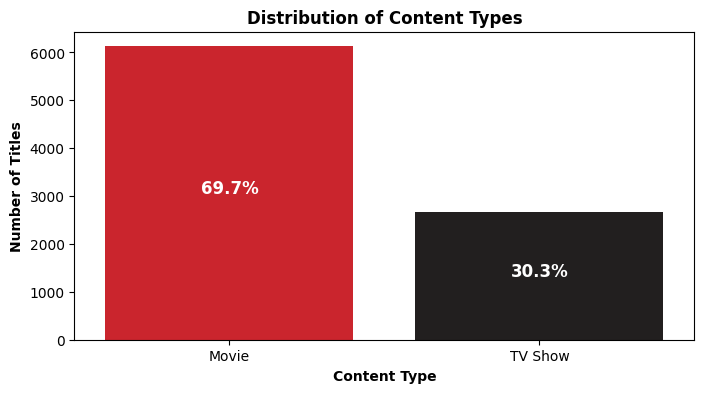

In [16]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="type", hue="type", palette=netflix_palette)
plt.title("Distribution of Content Types", fontsize=12, fontweight="bold")
plt.xlabel("Content Type", fontsize=10, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=10, fontweight="bold")
plt.text(0, 3063, '69.7%', fontsize=12, fontweight="bold", color='white', ha='center')
plt.text(1, 1332, '30.3%', fontsize=12, fontweight="bold", color='white', ha='center')
plt.show()

Movies dominate the Netflix dataset, while TV Shows make up a smaller portion. This imbalance affects comparisons between content types.

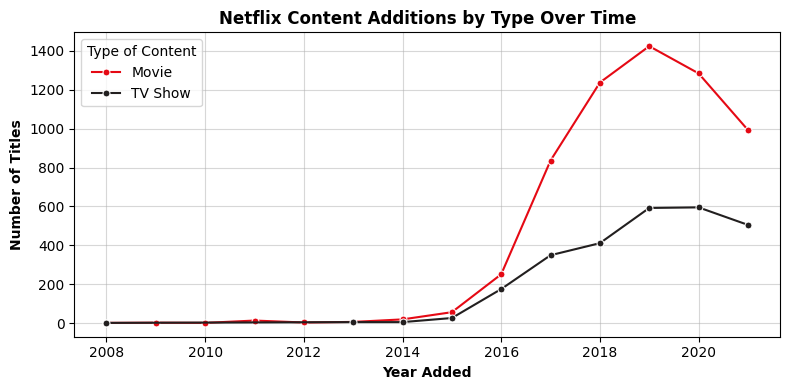

In [17]:
content_release_by_type = df[df["year_added"] >= 2000][["year_added", "type"]].value_counts().sort_index().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=content_release_by_type, x="year_added", y="count", hue="type", palette=netflix_palette, marker="o", markersize=5, errorbar=None)
plt.title("Netflix Content Additions by Type Over Time", fontsize=12, fontweight="bold")
plt.xlabel("Year Added", fontsize=10, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=10, fontweight="bold")
plt.grid(alpha=0.5)
plt.legend().set_title("Type of Content")
plt.tight_layout()
plt.show()

The number of titles added to Netflix increases sharply after 2015. Movies remain higher than TV Shows in most active years.

In [18]:
content_by_year = df[df["year_added"].between(2016, 2021)].groupby(["year_added", "type"])["type"].size().reset_index(name="count")
content_by_year["percentage"] = (content_by_year["count"] / content_by_year.groupby("year_added")["count"].transform("sum") * 100).round(1)

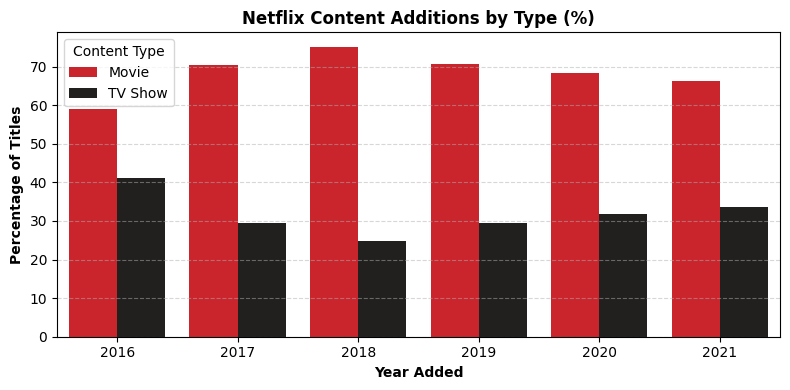

In [19]:
plt.figure(figsize=(8, 4))
sns.barplot(data=content_by_year, x="year_added", y="percentage", hue="type", palette=netflix_palette)

plt.title("Netflix Content Additions by Type (%)", fontsize=12, fontweight="bold")
plt.xlabel("Year Added", fontsize=10, fontweight="bold")
plt.ylabel("Percentage of Titles", fontsize=10, fontweight="bold")
plt.legend(title="Content Type")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Movies make up the majority of titles added in every year from 2016 to 2021. After 2018, the gap between Movies and TV Shows becomes smaller.

In [20]:
def rating_group(rating):
    if rating in ["TV-MA", "R", "NC-17"]:
        return "Adult"
    elif rating in ["TV-14", "PG-13"]:
        return "Teen"
    elif rating in ["G", "PG", "TV-G", "TV-PG", "TV-Y", "TV-Y7", "TV-Y7-FV"]:
        return "Kids/Family"
    elif rating in ["NR", "UR"]:
        return "Unrated"
    else:
        return "Unknown"

df["rating_group"] = df["rating"].apply(rating_group)

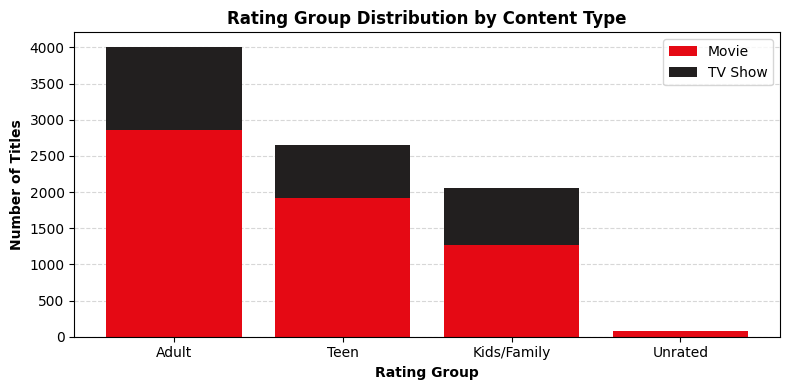

In [21]:
ratings = df.groupby(["rating_group", "type"])["type"].count().unstack(fill_value=0).reset_index().sort_values(by=["Movie", "TV Show"], ascending=[False, False])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x=ratings["rating_group"], height=ratings["Movie"], label="Movie", color="#E50914", zorder=2)
ax.bar(x=ratings["rating_group"], height=ratings["TV Show"], bottom=ratings["Movie"], label="TV Show", color="#221F1F", zorder=2)
plt.title("Rating Group Distribution by Content Type", fontsize=12, fontweight="bold")
plt.xlabel("Rating Group", fontsize=10, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=10, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.legend()
plt.tight_layout()
plt.show()

Adult content is the largest rating group in the dataset, followed by Teen and Kids/Family. Movies make up most titles in each rating group, which is expected because the dataset is movie-heavy overall.

This grouped view makes the rating distribution easier to compare than the raw rating categories.

In [22]:
movies = df[df["type"] == "Movie"].copy()

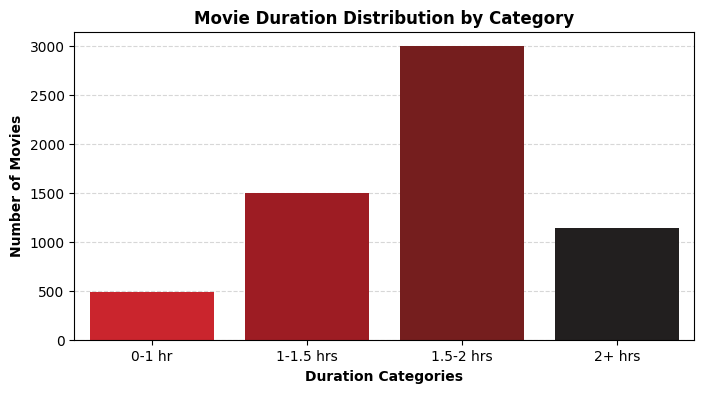

In [23]:
less_than_one_hour = 60
one_to_one_half_hour = 90
one_half_to_two_hour = 120
above_two_hours = movies["duration"].max()

labels = ["0-1 hr", "1-1.5 hrs", "1.5-2 hrs", "2+ hrs"]
bins = [0, less_than_one_hour, one_to_one_half_hour, one_half_to_two_hour, above_two_hours]

movies["duration_category"] = pd.cut(movies["duration"], labels=labels, bins=bins, right=True)
movie_duration_category = movies["duration_category"].value_counts().reset_index()

duration_palette = ["#E50914", "#B20710", "#831010", "#221F1F"]
plt.figure(figsize=(8, 4))
sns.barplot(data=movie_duration_category, x="duration_category", y="count", hue="duration_category", palette=duration_palette, zorder=2, dodge=False, legend=False)
plt.title("Movie Duration Distribution by Category", fontsize=12, fontweight="bold")
plt.xlabel("Duration Categories", fontsize=10, fontweight="bold")
plt.ylabel("Number of Movies", fontsize=10, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=1)
plt.show()

Most movies are concentrated in the 1.5–2 hour range. Very short movies are much less common, while movies over 2 hours still represent a visible part of the catalog.

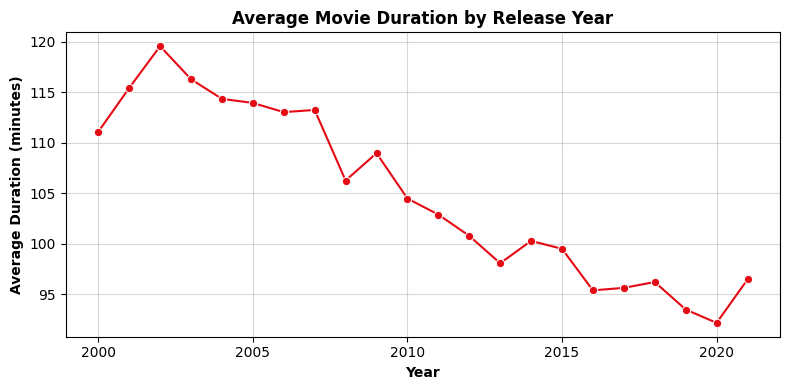

In [24]:
movie_duration_by_year = movies[movies["year"] >= 2000].groupby("year")["duration"].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=movie_duration_by_year, x="year", y="duration", marker="o", color="#E50914")
plt.title("Average Movie Duration by Release Year", fontsize=12, fontweight="bold")
plt.xlabel("Year", fontsize=10, fontweight="bold")
plt.ylabel("Average Duration (minutes)", fontsize=10, fontweight="bold")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

Average movie duration generally decreases after the early 2000s. This supports the next step of comparing movie duration categories across release eras.

In [25]:
def year_groups(year):
    if year <= 2010:
        return "Before 2010"
    elif year > 2010 and year <= 2015:
        return "2010-2015"
    elif year >= 2016 and year <= 2020:
        return "2016-2020"
    elif year > 2020:
        return "2021+"

movies["era"] = movies["year"].apply(year_groups)

movie_duration_categories_by_year = movies.groupby(["era", "duration_category"]).size().reset_index(name="count")

movie_duration_categories_by_year["percentage"] = (movie_duration_categories_by_year["count"] / 
                                                   movie_duration_categories_by_year.groupby("era")["count"].transform("sum") * 100).round(1)

era_order = ["Before 2010", "2010-2015", "2016-2020", "2021+"]

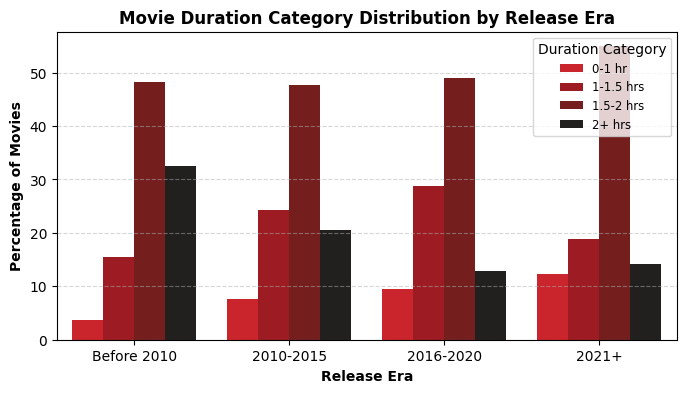

In [26]:
duration_palette = {"0-1 hr": "#E50914", "1-1.5 hrs": "#B20710", "1.5-2 hrs": "#831010", "2+ hrs": "#221F1F"}
plt.figure(figsize=(8, 4))
sns.barplot(data=movie_duration_categories_by_year, x="era", y="percentage", hue="duration_category", palette=duration_palette, order=era_order)
plt.title("Movie Duration Category Distribution by Release Era", fontsize=12, fontweight="bold")
plt.xlabel("Release Era", fontsize=10, fontweight="bold")
plt.ylabel("Percentage of Movies", fontsize=10, fontweight="bold")
plt.legend(title="Duration Category", fontsize="small", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

The 1.5–2 hour category remains the largest group across all release eras. Movies over 2 hours are more common before 2010, while shorter categories become more visible in later eras.